# **DATA CLEANING**

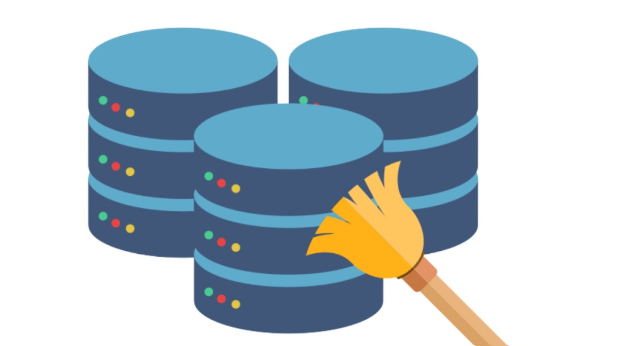

In [1]:
from PIL import Image as i
i.open('clean.png')

In [2]:
%store -r my_library

In [3]:
my_library

All the libraries are loaded successfully! ✅


In [4]:
print(my_library)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import numpy as np
import sklearn       
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy import stats                    # statistical tests
import statsmodels.api as sm              # regression, statistical models
import pyarrow.parquet as pq              # direct parquet schema inspection
import glob                               # find multiple files (*.parquet, *.csv)
import json                               # read/write JSON files
from pathlib import Path                  # better than os for file paths
import warnings
warnings.filterwarnings('ignore')          # suppress unnecessary warnings

pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.max_rows', 100)      # show more rows
pd.set_option('display.float_format', '{:.2f

# *1. Load the data*

In [5]:
df = pd.read_csv('titanic_data.csv');

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S


# *2. Finding the Misssing Data*

In [7]:
d = df.isna().sum().reset_index();
print(f"Total Missing Values : {df.isna().sum().sum()}");
d = d.rename(columns = {0:'count'})
d

Total Missing Values : 866


,index,count
0,PassengerId,0
1,Survived,0
2,Pclass,0
3,Name,0
4,Sex,0
5,Age,177
6,SibSp,0
7,Parch,0
8,Ticket,0
9,Fare,0


In [8]:
age = d.loc[d['index']=='Age','count'].values[0]
cabin = d.loc[d['index']=='Cabin','count'].values[0]

In [9]:
z = (age/866)*100
a = (cabin/866)*100
print(f'Age column has : {z:.2f}% of missing data')
print(f'Cabin column has : {a:.2f}% of missing data')

Age column has : 20.44% of missing data
Cabin column has : 79.33% of missing data


# *3. Handle Missing Data*

## Cabin - We can drop it 

In [10]:
df['Has_Cabin'] = df['Cabin'].notna().astype(int)
df['Has_Cabin']

0      0
1      1
2      0
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Has_Cabin, Length: 891, dtype: int64

# *4.Survival Rate by Having Cabin*

In [11]:
df.groupby('Has_Cabin')['Survived'].mean()

Has_Cabin
0   0.30
1   0.67
Name: Survived, dtype: float64

## *Passengers with cabin numbers had higher chances of survival Rate*
### *we can drop the Cabin column and keep Has_Cabin*

In [12]:
df = df.drop(columns = ['Cabin'])

In [13]:
df.groupby(['Pclass','Sex'])['Age'].median()

Pclass  Sex   
1       female   35.00
        male     40.00
2       female   28.00
        male     30.00
3       female   21.50
        male     25.00
Name: Age, dtype: float64

## *Filling the Null values with Group Median*

In [14]:
df['Age'] = df.groupby(['Pclass','Sex'])['Age'].transform(lambda x:x.fillna(x.median()))

## *Filling left over null values if exist*

In [15]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [16]:
print(f'The number of missing values are inserting with appropriate Value: {df['Age'].isna().sum()}')

The number of missing values are inserting with appropriate Value: 0


# *5. Visualization of Age distribution*

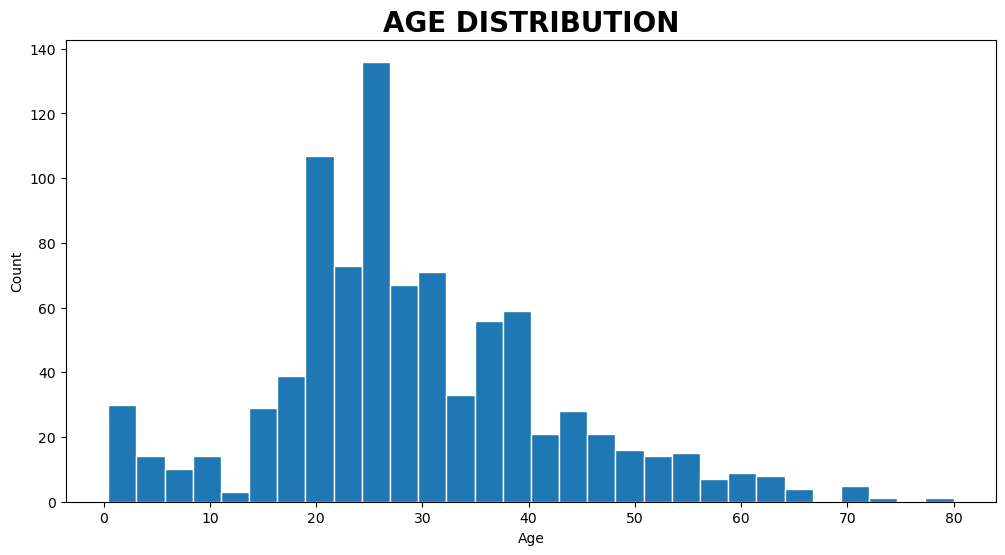

In [17]:
fig,ax = plt.subplots(figsize = (12,6));
ax.hist(df['Age'],bins = 30,edgecolor = 'white');
ax.set_xlabel('Age');
ax.set_ylabel('Count');
ax.set_title('AGE DISTRIBUTION',fontweight = 'bold',fontsize = 20);

In [18]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
Has_Cabin      0
dtype: int64

# *6. Now working with Embarked feature*

In [19]:
print(f'Number of Missing Embarked Data : {df['Embarked'].isna().sum()}')
print(f'Mode of Embarked : {df['Embarked'].mode()[0]}')

Number of Missing Embarked Data : 2
Mode of Embarked : S


# *Since Embarked contains Text data and only three category of text we cannot apply mean and median as they work with numbers only.so we find the mode and fill the empty spaces with the mode of the feature*

In [20]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [21]:
print(f'Missing data in Embarked Feature after Operation : {df['Embarked'].isna().sum()}')

Missing data in Embarked Feature after Operation : 0


# *Let's Check whether we have any more missing values left or not*

In [22]:
print('Missing Values : ')
print(df.isna().sum())
print(f'Total Missing Values after cleaning : {df.isna().sum().sum()}')

Missing Values : 
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64
Total Missing Values after cleaning : 0


# *7. FEATURE ENGINEERING*

## *7.1 Title Extraction from the name column*

In [23]:
df['Name'].head(2)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
Name: Name, dtype: object

In [24]:
df['Title'] = df['Name'].apply(lambda x :x.split(',')[1].split('.')[0])
df['Title']

0         Mr
1        Mrs
2       Miss
3        Mrs
4         Mr
       ...  
886      Rev
887     Miss
888     Miss
889       Mr
890       Mr
Name: Title, Length: 891, dtype: object

In [25]:
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [26]:
title_map = {
            'Mr':'Mr',
            'Miss':'Miss',
            'Mrs':'Mrs',
            'Master':'Master'
            }
df['Title'] = df['Title'].apply(lambda x: title_map.get(x.strip().title(),'rare'));
df['Title']

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886    rare
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: object

## *Survival Rate by Title*

In [27]:
df.groupby('Title')['Survived'].mean().sort_values(ascending = True).reset_index()

,Title,Survived
0,Mr,0.16
1,rare,0.44
2,Master,0.57
3,Miss,0.70
4,Mrs,0.79


## *7.2 Family Size and IsAlone Analysis*

In [28]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,S,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C,1,Mrs


In [29]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
df['Family_Size']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: Family_Size, Length: 891, dtype: int64

In [30]:
df['IsAlone'] = (df['Family_Size']==1).astype(int)
df['IsAlone']

0      0
1      0
2      1
3      0
4      1
      ..
886    1
887    1
888    0
889    1
890    1
Name: IsAlone, Length: 891, dtype: int64

In [31]:
print(f'Number of Solo Travellers  : {df['IsAlone'].sum()} [mean : {df['IsAlone'].mean():.2%}]')
print(f'Survival Rate Alone : {df[df['IsAlone']==1]['Survived'].mean():.2%}')
print(f'Survival Rate with Family : {df[df['IsAlone']==0]['Survived'].mean():.2%}')

Number of Solo Travellers  : 537 [mean : 60.27%]
Survival Rate Alone : 30.35%
Survival Rate with Family : 50.56%


## *7.3 Age Groups*

In [32]:
print(f'Oldest Age of person in the data : {df['Age'].max()} years ')
print(f'Youngest Age of person in the data : {df['Age'].min()} years ')

Oldest Age of person in the data : 80.0 years 
Youngest Age of person in the data : 0.42 years 


In [33]:
df['AgeGroup'] = pd.cut(df['Age'],bins = [0,12,18,35,60,80],labels = ['child','Teen','Young Adult','Adult','Senior'])
df['AgeGroup']

0      Young Adult
1            Adult
2      Young Adult
3      Young Adult
4      Young Adult
          ...     
886    Young Adult
887    Young Adult
888    Young Adult
889    Young Adult
890    Young Adult
Name: AgeGroup, Length: 891, dtype: category
Categories (5, object): ['child' < 'Teen' < 'Young Adult' < 'Adult' < 'Senior']

In [34]:
df['AgeGroup'].value_counts().sort_index().reset_index()

,AgeGroup,count
0,child,69
1,Teen,70
2,Young Adult,514
3,Adult,216
4,Senior,22


# *Survival Rate by Agegroup*

In [35]:
df.groupby('AgeGroup')['Survived'].mean().reset_index()

,AgeGroup,Survived
0,child,0.58
1,Teen,0.43
2,Young Adult,0.36
3,Adult,0.38
4,Senior,0.23


# 7.4 *Fare Bins*

In [36]:
df['Farebins'] = pd.qcut(df['Fare'],q=4,labels = ['Low','medium','High','Very High'])
df['Farebins']

0            Low
1      Very High
2         medium
3      Very High
4         medium
         ...    
886       medium
887         High
888         High
889         High
890          Low
Name: Farebins, Length: 891, dtype: category
Categories (4, object): ['Low' < 'medium' < 'High' < 'Very High']

# *Survival Rate by Fare Bin*

In [37]:
df.groupby('Farebins')['Survived'].mean().reset_index()

,Farebins,Survived
0,Low,0.20
1,medium,0.30
2,High,0.45
3,Very High,0.58


# *Categorical Variable Overview*

In [38]:
df.dtypes

PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
Has_Cabin         int64
Title            object
Family_Size       int64
IsAlone           int64
AgeGroup       category
Farebins       category
dtype: object

In [39]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,Title,Family_Size,IsAlone,AgeGroup,Farebins
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,S,0,Mr,2,0,Young Adult,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C,1,Mrs,2,0,Adult,Very High
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,S,0,Miss,1,1,Young Adult,medium
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,S,1,Mrs,2,0,Young Adult,Very High
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,S,0,Mr,1,1,Young Adult,medium


In [ ]:
print(df.dtypes)
print(df.shape)

## *8. Encode Sex Column*
### *Male : 0 and Female :1*

In [ ]:
df['Sex'] = df['Sex'].map({'male' : 0,'female' : 1})

In [ ]:
df.head()

## *9. We can drop the unnecessary columns (not to be used for modelling)*

In [ ]:
columns = ['Name','PassengerId','Ticket']
df  = df.drop(columns = columns)

In [ ]:
df

In [ ]:
df.columns

# *10. Final Checkup of the data*

In [ ]:
print(f'Total Missing Data : {df.isna().sum().sum()}')
print(f'Columns : {df.columns}')
print(f'Shape : {df.shape}')
print(f'Data types of the data : \n{df.dtypes}')

# *11. Save the clean Data*

In [ ]:
df.to_csv('cleaned_titanic_data.csv',index = False)
print('Cleaned Data : ')
print(f'Shape : {df.shape}')
df.head()

# *12. SUMMARY*

|**Steps**|**Description**|
|---------|---------------|
|**Cabin**|*Created Has_Cabin column having binary data as 1 : have cabin , 0 : does not have cabin*|
|**Age**|*Worked by handling missing values using group median with (Pclass and Sex)*|
|**Embarked**|*Filled the 2 empty spaces with the mode of the data*|
|**Title**|*Extracted Title from the Name column, grouped rare titles*|
|**Family Size**|*Created by Sibsp(Siblings/Spouses) + Parch(Parents/Children) + 1(ownself)*|
|**IsAlone**|binary Data ,1 : is Alone,0 : is Not Alone|
|**Age**|*Binned or (buket) ages into 5 categories*|
|**FareBin**|*Binned fare into 4 categories (low < medium < high < very high)*|
|*Enconding*|*Encoded sex column 0 as males and 1 as females*|
|**Dropped Columns**|*Dropped PassengerId,Name,Ticket columns*|